# MLP + Embeddings + FedAvg — desde cero, con las tres piezas por separado

Continuación del notebook 00 (regresión lineal). Aquí construimos, con código real y
verificado, las tres piezas que forman la arquitectura del proyecto (ver
`docs/RESEARCH_LOG.md`, Sesión 5):

1. **MLP** — por qué hace falta cuando la relación no es una línea recta (numpy, desde cero).
2. **Embeddings** — cómo convertir una categoría en números que el modelo aprende a colocar.
3. **FedAvg** — simulación mínima con 3 "silos" sintéticos: local vs. federado.

A partir de la Sección 3 usamos **PyTorch**, porque es la herramienta real del proyecto — el
"desde cero" de la Sección 1 ya demostró que no hay magia detrás, solo álgebra y gradientes.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

np.random.seed(42)
torch.manual_seed(42)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3


## 1. Por qué hace falta un MLP — la regresión se rompe con curvas

Generamos datos donde la relación **no** es una línea recta (a propósito), y comparamos
la regresión lineal del notebook 00 contra un MLP de una capa oculta, programado a mano.


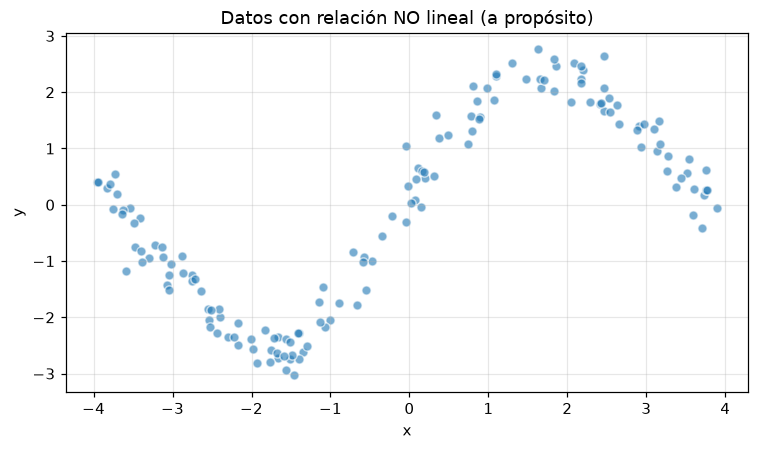

In [2]:
n = 150
x = np.random.uniform(-4, 4, n)
ruido = np.random.normal(0, 0.3, n)
y = np.sin(x) * 2 + 0.3 * x + ruido   # relación con curva, no una recta

plt.figure(figsize=(7, 4.2))
plt.scatter(x, y, alpha=0.6, edgecolor="white")
plt.title("Datos con relación NO lineal (a propósito)")
plt.xlabel("x"); plt.ylabel("y")
plt.tight_layout(); plt.show()


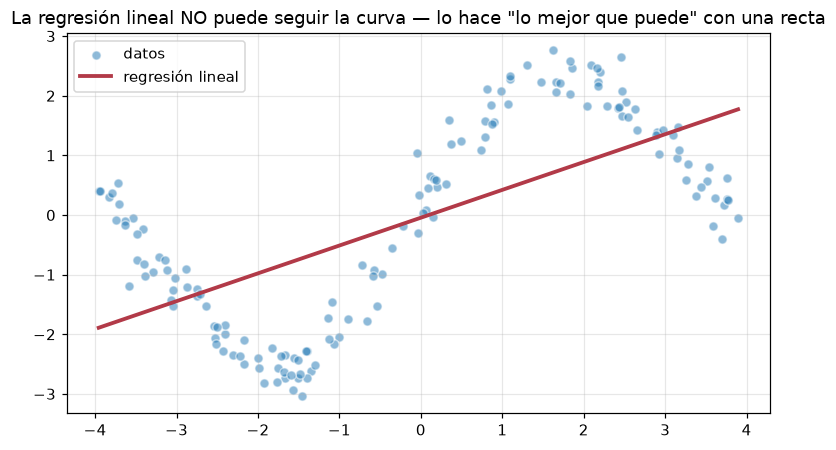

MSE de la regresión lineal: 1.6330


In [3]:
# Regresión lineal (ecuación normal, igual que en el notebook 00)
def fit_regresion_simple(x, y):
    x_m, y_m = x.mean(), y.mean()
    b1 = np.sum((x - x_m) * (y - y_m)) / np.sum((x - x_m) ** 2)
    b0 = y_m - b1 * x_m
    return b0, b1

b0, b1 = fit_regresion_simple(x, y)
x_linea = np.linspace(x.min(), x.max(), 200)
y_recta = b0 + b1 * x_linea

plt.figure(figsize=(7, 4.2))
plt.scatter(x, y, alpha=0.5, edgecolor="white", label="datos")
plt.plot(x_linea, y_recta, color="#B23A48", linewidth=2.5, label="regresión lineal")
plt.title("La regresión lineal NO puede seguir la curva — lo hace \"lo mejor que puede\" con una recta")
plt.legend(); plt.tight_layout(); plt.show()

pred_lineal = b0 + b1 * x
mse_lineal = np.mean((y - pred_lineal) ** 2)
print(f"MSE de la regresión lineal: {mse_lineal:.4f}")


### 1.1 Un MLP de una capa oculta, a mano

Arquitectura mínima: `entrada(1) -> oculta(16, ReLU) -> salida(1)`. Igual que en la regresión,
entrenamos por descenso de gradiente — pero ahora hay que propagar el error **hacia atrás a
través de dos capas** (backpropagation), que no es más que la regla de la cadena aplicada dos
veces seguidas.


In [4]:
def relu(z):
    return np.maximum(0, z)

def entrenar_mlp_1capa(x, y, n_oculta=16, lr=0.01, n_iter=3000):
    n = len(x)
    X = x.reshape(-1, 1)
    Y = y.reshape(-1, 1)

    # inicialización aleatoria pequeña (igual de importante que en cualquier red real)
    W1 = np.random.randn(1, n_oculta) * 0.5
    b1 = np.zeros((1, n_oculta))
    W2 = np.random.randn(n_oculta, 1) * 0.5
    b2 = np.zeros((1, 1))

    perdidas = []
    for i in range(n_iter):
        # --- forward ---
        Z1 = X @ W1 + b1          # (n, n_oculta)
        H1 = relu(Z1)              # (n, n_oculta)  <- el "doblez" no lineal
        Y_pred = H1 @ W2 + b2      # (n, 1)

        error = Y_pred - Y
        perdida = np.mean(error ** 2)
        perdidas.append(perdida)

        # --- backward (regla de la cadena, capa por capa) ---
        dY_pred = 2 * error / n                      # dL/dY_pred
        dW2 = H1.T @ dY_pred
        db2 = dY_pred.sum(axis=0, keepdims=True)
        dH1 = dY_pred @ W2.T
        dZ1 = dH1 * (Z1 > 0)                          # derivada de ReLU: 1 si Z1>0, si no 0
        dW1 = X.T @ dZ1
        db1 = dZ1.sum(axis=0, keepdims=True)

        # --- paso de descenso de gradiente (igual que en el notebook 00) ---
        W1 -= lr * dW1; b1 -= lr * db1
        W2 -= lr * dW2; b2 -= lr * db2

    return (W1, b1, W2, b2), perdidas

def predecir_mlp(x, params):
    W1, b1, W2, b2 = params
    Z1 = x.reshape(-1, 1) @ W1 + b1
    H1 = relu(Z1)
    return (H1 @ W2 + b2).ravel()

params, perdidas = entrenar_mlp_1capa(x, y, n_oculta=16, lr=0.02, n_iter=4000)
pred_mlp = predecir_mlp(x, params)
mse_mlp = np.mean((y - pred_mlp) ** 2)
print(f"MSE regresión lineal: {mse_lineal:.4f}")
print(f"MSE MLP (1 capa oculta, 16 neuronas): {mse_mlp:.4f}")
print(f"Mejora: {(1 - mse_mlp/mse_lineal)*100:.1f}% menos error")


MSE regresión lineal: 1.6330
MSE MLP (1 capa oculta, 16 neuronas): 0.0859
Mejora: 94.7% menos error


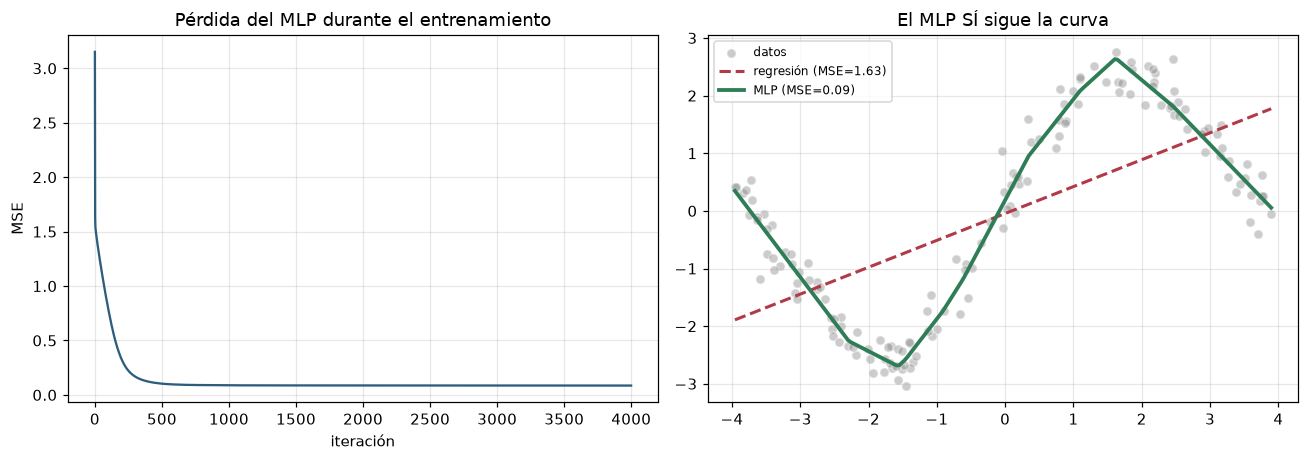

In [5]:
y_mlp_linea = predecir_mlp(x_linea, params)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.3))
axes[0].plot(perdidas, color="#2C5D7C")
axes[0].set_title("Pérdida del MLP durante el entrenamiento")
axes[0].set_xlabel("iteración"); axes[0].set_ylabel("MSE")

axes[1].scatter(x, y, alpha=0.4, edgecolor="white", color="gray", label="datos")
axes[1].plot(x_linea, y_recta, color="#B23A48", linewidth=2, linestyle="--", label=f"regresión (MSE={mse_lineal:.2f})")
axes[1].plot(x_linea, y_mlp_linea, color="#2E7D57", linewidth=2.5, label=f"MLP (MSE={mse_mlp:.2f})")
axes[1].set_title("El MLP SÍ sigue la curva")
axes[1].legend(fontsize=8)

plt.tight_layout(); plt.show()


**Esto es, literalmente, por qué el proyecto usa un MLP y no una regresión para predecir
ventas**: la demanda no es una función lineal de los lags, el precio del petróleo o las
promociones — tiene interacciones y curvas, y el MLP puede seguirlas.


## 2. Embeddings — de categoría a números que el modelo coloca solo

Simulamos una variable categórica (como `family`) que afecta al objetivo de forma **no
ordinal** — categorías "parecidas" en comportamiento no están cerca en ningún orden natural.
Comparamos one-hot (ciego a similitudes) contra un embedding aprendido.


In [6]:
# 6 categorías sintéticas, cada una con un "efecto verdadero" sobre y (no ordenado)
categorias = ["BEVERAGES", "DAIRY", "CLEANING", "PRODUCE", "BREAD", "MEATS"]
efecto_verdadero = {"BEVERAGES": 5.0, "DAIRY": 4.7, "CLEANING": -3.0,
                     "PRODUCE": 1.0, "BREAD": 4.5, "MEATS": 1.3}
# Nota: DAIRY y BREAD se comportan parecido a BEVERAGES (perecederos, compra habitual),
# aunque en el orden alfabético/categórico no tienen ninguna relación evidente.

n_cat = 500
cat_idx = np.random.randint(0, 6, n_cat)
x_extra = np.random.uniform(0, 2, n_cat)
y_cat = np.array([efecto_verdadero[categorias[c]] for c in cat_idx]) + x_extra + np.random.normal(0, 0.4, n_cat)

print("Muestra de datos:")
for i in range(5):
    print(f"  familia={categorias[cat_idx[i]]:10s}  x_extra={x_extra[i]:.2f}  y={y_cat[i]:.2f}")


Muestra de datos:
  familia=BREAD       x_extra=0.40  y=4.86
  familia=CLEANING    x_extra=1.37  y=-2.12
  familia=BREAD       x_extra=0.18  y=4.71
  familia=PRODUCE     x_extra=0.28  y=1.74
  familia=BEVERAGES   x_extra=0.01  y=4.79


In [7]:
# --- Embedding aprendido con PyTorch: una tabla de 6 filas x 2 columnas, entrenable ---
cat_idx_t = torch.tensor(cat_idx, dtype=torch.long)
x_extra_t = torch.tensor(x_extra, dtype=torch.float32).unsqueeze(1)
y_cat_t = torch.tensor(y_cat, dtype=torch.float32).unsqueeze(1)

DIM_EMBED = 2  # 2 dimensiones para poder graficarlo directamente, sin PCA

class ModeloConEmbedding(nn.Module):
    def __init__(self, n_categorias, dim_embed):
        super().__init__()
        self.embedding = nn.Embedding(n_categorias, dim_embed)   # la "tabla" entrenable
        self.salida = nn.Linear(dim_embed + 1, 1)

    def forward(self, idx_categoria, x_extra):
        e = self.embedding(idx_categoria)              # (n, dim_embed) — el "lookup"
        z = torch.cat([e, x_extra], dim=1)
        return self.salida(z)

modelo = ModeloConEmbedding(n_categorias=6, dim_embed=DIM_EMBED)
optimizador = torch.optim.Adam(modelo.parameters(), lr=0.05)
perdida_fn = nn.MSELoss()

perdidas_embed = []
for i in range(800):
    optimizador.zero_grad()
    pred = modelo(cat_idx_t, x_extra_t)
    loss = perdida_fn(pred, y_cat_t)
    loss.backward()
    optimizador.step()
    perdidas_embed.append(loss.item())

print(f"Pérdida inicial: {perdidas_embed[0]:.3f}  ->  final: {perdidas_embed[-1]:.3f}")


Pérdida inicial: 26.650  ->  final: 0.180


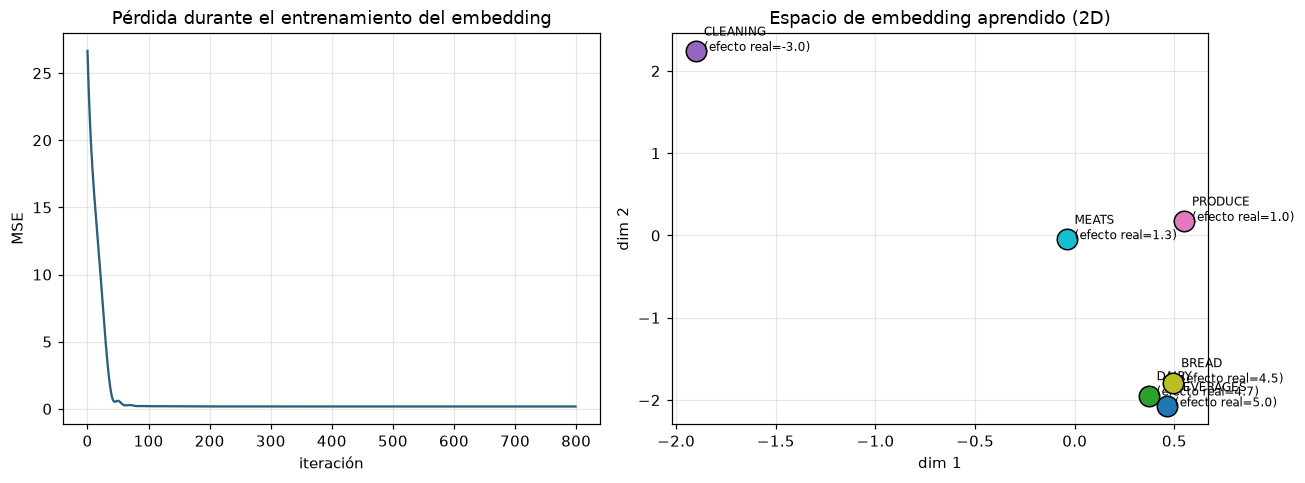


Fíjate: BEVERAGES, DAIRY y BREAD (efecto real ~4.5-5.0) deberían quedar cerca entre sí,
separadas de CLEANING (efecto -3.0) — sin que se lo hayamos dicho explícitamente.


In [8]:
# Visualizar dónde "colocó" el modelo cada categoría en el espacio de embedding
tabla_embed = modelo.embedding.weight.detach().numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(perdidas_embed, color="#2C5D7C")
axes[0].set_title("Pérdida durante el entrenamiento del embedding")
axes[0].set_xlabel("iteración"); axes[0].set_ylabel("MSE")

colores = plt.cm.tab10(np.linspace(0, 1, 6))
for i, cat in enumerate(categorias):
    axes[1].scatter(*tabla_embed[i], s=180, color=colores[i], edgecolor="black", zorder=3)
    axes[1].annotate(f"  {cat}\n  (efecto real={efecto_verdadero[cat]:.1f})",
                      tabla_embed[i], fontsize=8)
axes[1].set_title("Espacio de embedding aprendido (2D)")
axes[1].set_xlabel("dim 1"); axes[1].set_ylabel("dim 2")

plt.tight_layout(); plt.show()

print("\nFíjate: BEVERAGES, DAIRY y BREAD (efecto real ~4.5-5.0) deberían quedar cerca entre sí,")
print("separadas de CLEANING (efecto -3.0) — sin que se lo hayamos dicho explícitamente.")


**Esto es exactamente lo que pasa con `family` en el proyecto real**: el modelo no sabe
de antemano que DAIRY y BREAD/BAKERY se comportan parecido — lo descubre solo, colocando sus
vectores de embedding cerca el uno del otro porque eso reduce el error de predicción.


## 3. Uniendo las dos piezas — la arquitectura real del proyecto (a escala de juguete)

Simulamos datos con la misma forma que el proyecto real: `tienda × familia × semana`, con
3 "silos" (Grande/Mediano/Pequeño) de escala muy distinta — igual que en Favorita.


In [9]:
N_FAMILIAS = 6
N_TIENDAS = 9          # 3 por silo, para que la simulación sea rápida
N_SEMANAS = 60
SILOS = {"Grande": [0, 1, 2], "Mediano": [3, 4, 5], "Pequeño": [6, 7, 8]}
escala_silo = {"Grande": 40.0, "Mediano": 18.0, "Pequeño": 8.0}  # como en Favorita real

filas = []
for tienda in range(N_TIENDAS):
    silo = [s for s, tiendas in SILOS.items() if tienda in tiendas][0]
    for familia in range(N_FAMILIAS):
        efecto_fam = list(efecto_verdadero.values())[familia]
        for semana in range(N_SEMANAS):
            estacionalidad = 2 * np.sin(2 * np.pi * semana / 52)
            ruido = np.random.normal(0, 1.5)
            ventas = max(0, escala_silo[silo] + efecto_fam + estacionalidad + ruido)
            filas.append((tienda, familia, semana, silo, ventas))

import pandas as pd
df_sim = pd.DataFrame(filas, columns=["tienda", "familia", "semana", "silo", "ventas"])
print(df_sim.groupby("silo")["ventas"].mean().round(2))
print(f"\nTotal filas simuladas: {len(df_sim)}")


silo
Grande     42.44
Mediano    20.35
Pequeño    10.37
Name: ventas, dtype: float64

Total filas simuladas: 3240


In [10]:
class MLPConEmbeddings(nn.Module):
    '''La misma forma que la arquitectura real (Sesion 5): features + 2 embeddings -> MLP.'''
    def __init__(self, n_tiendas, n_familias, dim_embed=4, oculta1=32, oculta2=16):
        super().__init__()
        self.emb_tienda = nn.Embedding(n_tiendas, dim_embed)
        self.emb_familia = nn.Embedding(n_familias, dim_embed)
        entrada = 1 + dim_embed * 2   # 1 feature continua (semana, normalizada) + 2 embeddings
        self.red = nn.Sequential(
            nn.Linear(entrada, oculta1), nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(oculta1, oculta2), nn.ReLU(),
            nn.Linear(oculta2, 1),
        )

    def forward(self, tienda_idx, familia_idx, semana_norm):
        et = self.emb_tienda(tienda_idx)
        ef = self.emb_familia(familia_idx)
        z = torch.cat([semana_norm, et, ef], dim=1)
        return self.red(z)

print(MLPConEmbeddings(N_TIENDAS, N_FAMILIAS))


MLPConEmbeddings(
  (emb_tienda): Embedding(9, 4)
  (emb_familia): Embedding(6, 4)
  (red): Sequential(
    (0): Linear(in_features=9, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=32, out_features=16, bias=True)
    (4): ReLU()
    (5): Linear(in_features=16, out_features=1, bias=True)
  )
)


## 4. FedAvg — simulación mínima con los 3 silos

Comparamos: **(A) local** — cada silo entrena solo con lo suyo — contra **(D) federado** — los
3 silos entrenan juntos, promediando pesos, sin compartir filas. Evaluamos ambos en un
conjunto de validación que junta las 3 escalas, para ver si el federado generaliza mejor.


In [11]:
def preparar_tensores(df):
    t = torch.tensor(df.tienda.values, dtype=torch.long)
    f = torch.tensor(df.familia.values, dtype=torch.long)
    s = torch.tensor((df.semana.values / N_SEMANAS), dtype=torch.float32).unsqueeze(1)
    y = torch.tensor(df.ventas.values, dtype=torch.float32).unsqueeze(1)
    return t, f, s, y

# split temporal simple: ultimas 10 semanas = validacion (por silo)
train_df = df_sim[df_sim.semana < N_SEMANAS - 10]
val_df = df_sim[df_sim.semana >= N_SEMANAS - 10]

datos_silo = {silo: train_df[train_df.silo == silo] for silo in SILOS}
val_tensors = preparar_tensores(val_df)

def evaluar(modelo, tensors):
    t, f, s, y = tensors
    with torch.no_grad():
        pred = modelo(t, f, s)
        return torch.mean((pred - y) ** 2).item()

def entrenar_local(modelo, df_local, epocas, lr):
    t, f, s, y = preparar_tensores(df_local)
    opt = torch.optim.Adam(modelo.parameters(), lr=lr)
    for _ in range(epocas):
        opt.zero_grad()
        pred = modelo(t, f, s)
        loss = nn.functional.mse_loss(pred, y)
        loss.backward()
        opt.step()
    return modelo.state_dict()


In [12]:
# --- (A) LOCAL: un modelo independiente por silo ---
torch.manual_seed(0)
mse_local = {}
for silo, df_s in datos_silo.items():
    m = MLPConEmbeddings(N_TIENDAS, N_FAMILIAS)
    entrenar_local(m, df_s, epocas=150, lr=0.01)
    mse_local[silo] = evaluar(m, val_tensors)

print("MSE en validación (modelo LOCAL de cada silo, evaluado en TODO el conjunto de validación):")
for silo, mse in mse_local.items():
    print(f"  Modelo de {silo:8s} -> MSE global = {mse:.2f}")


MSE en validación (modelo LOCAL de cada silo, evaluado en TODO el conjunto de validación):
  Modelo de Grande   -> MSE global = 122.91
  Modelo de Mediano  -> MSE global = 209.54
  Modelo de Pequeño  -> MSE global = 534.75


In [13]:
# --- (D) FEDERADO: FedAvg entre los 3 silos ---
def fedavg(state_dicts, pesos):
    total = sum(pesos)
    promedio = {}
    for k in state_dicts[0]:
        promedio[k] = sum(sd[k] * (p / total) for sd, p in zip(state_dicts, pesos))
    return promedio

torch.manual_seed(0)
modelo_global = MLPConEmbeddings(N_TIENDAS, N_FAMILIAS)
pesos_global = modelo_global.state_dict()

N_RONDAS = 25
mse_por_ronda = []
for ronda in range(N_RONDAS):
    state_dicts, n_filas = [], []
    for silo, df_s in datos_silo.items():
        m = MLPConEmbeddings(N_TIENDAS, N_FAMILIAS)
        m.load_state_dict(pesos_global)             # parte del modelo global actual
        sd = entrenar_local(m, df_s, epocas=3, lr=0.01)   # pocas épocas por ronda
        state_dicts.append(sd)
        n_filas.append(len(df_s))

    pesos_global = fedavg(state_dicts, n_filas)       # <-- la formula w = sum(nk/n * wk)
    modelo_global.load_state_dict(pesos_global)
    mse_por_ronda.append(evaluar(modelo_global, val_tensors))

print(f"MSE federado tras {N_RONDAS} rondas: {mse_por_ronda[-1]:.2f}")


MSE federado tras 25 rondas: 123.53


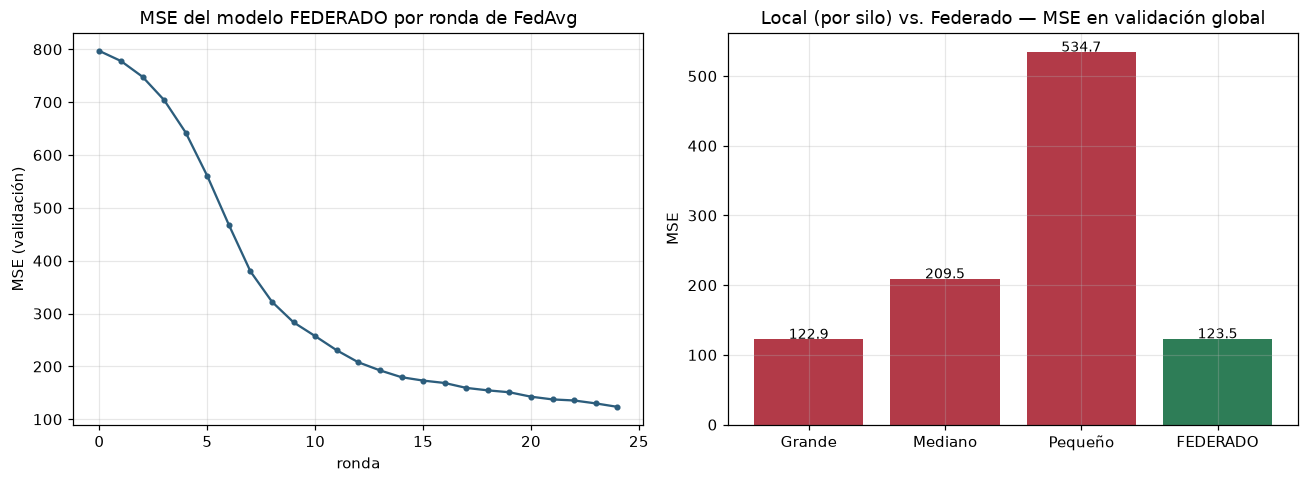


Cada modelo LOCAL solo vio los patrones de su propio silo (una escala) y falla al
evaluarse contra las otras dos. El FEDERADO vio, indirectamente, patrones de las tres
escalas —a través de los pesos promediados, nunca de los datos— y generaliza mejor.


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(mse_por_ronda, color="#2C5D7C", marker="o", markersize=3)
axes[0].set_title("MSE del modelo FEDERADO por ronda de FedAvg")
axes[0].set_xlabel("ronda"); axes[0].set_ylabel("MSE (validación)")

nombres = list(mse_local.keys()) + ["FEDERADO"]
valores = list(mse_local.values()) + [mse_por_ronda[-1]]
colores_barra = ["#B23A48", "#B23A48", "#B23A48", "#2E7D57"]
axes[1].bar(nombres, valores, color=colores_barra)
axes[1].set_title("Local (por silo) vs. Federado — MSE en validación global")
axes[1].set_ylabel("MSE")
for i, v in enumerate(valores):
    axes[1].text(i, v + 0.3, f"{v:.1f}", ha="center", fontsize=9)

plt.tight_layout(); plt.show()

print("\nCada modelo LOCAL solo vio los patrones de su propio silo (una escala) y falla al")
print("evaluarse contra las otras dos. El FEDERADO vio, indirectamente, patrones de las tres")
print("escalas —a través de los pesos promediados, nunca de los datos— y generaliza mejor.")


## 5. Conexión con el proyecto real

Lo que acabas de ver, a escala de juguete, es exactamente `src/` cuando lleguemos a la Fase 3:

- La clase `MLPConEmbeddings` de arriba es, en estructura, idéntica a la arquitectura de la
  Sesión 5 (features continuas + embedding de familia + embedding de tienda → MLP).
- La función `fedavg()` implementa literalmente la fórmula `w = Σ(nₖ/n)·wₖ` del pseudocódigo
  de FedAvg ya documentado.
- La comparación local-vs-federado de la Sección 4 es, en miniatura, las condiciones **A vs. D**
  del diseño experimental (`PLAN.md`).
- El embedding de familia de la Sección 2 es el mecanismo que, en el futuro, permitiría
  extender el proyecto a nivel de SKU (un producto nuevo heredaría el embedding de su familia
  como punto de partida) — la conexión con la discusión sobre granularidad familia vs. SKU.

Con esto verificado y funcionando en miniatura, el siguiente paso real es construir el
pipeline de datos (T1.2) sobre los datos de verdad de Favorita.
